In [ ]:
import zipfile, os
from google.colab import drive
drive.mount('/content/drive')

# Extract the zip directly in Colab
zip_path    = '/content/drive/MyDrive/NLP_Project.zip'
extract_to  = '/content/drive/MyDrive/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Extracted! Folder is ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted! Folder is ready.


# ⚙️ Stage 2.4 — LLM Fine-Tuning with LoRA (T5-base + PEFT)
## Syntactic Simplification of Long Sentences | NLP Course Project

---

### What this notebook does:
1. ✅ Installs HuggingFace PEFT, bitsandbytes, transformers
2. ✅ Loads preprocessed Newsela data from Google Drive
3. ✅ Fine-tunes **T5-base** (250M params) using **LoRA** (Low-Rank Adaptation)
4. ✅ Fine-tunes **BART-large** (400M params) using **LoRA**
5. ✅ Generates predictions with beam search
6. ✅ Evaluates SARI, BLEU, FKGL
7. ✅ Builds **full 4-system comparison table** (Rule-Based vs T5-small vs BART-base vs LLM)
8. ✅ Saves everything to Google Drive

> 💡 **Why LoRA?** T5-base and BART-large are too large to fully fine-tune on a free
> Colab T4 GPU (16GB). LoRA freezes most weights and only trains small adapter
> matrices — reducing trainable parameters by ~99% while keeping quality high.

> ⏱️ Expected training time: ~20–30 min per model on Colab T4 GPU

---
## 🔧 CELL 1 — Install Libraries

In [ ]:
# ============================================================
# CELL 1 — Install all required libraries
# ⚠️ After this cell finishes:
#    1. Go to Runtime > Restart Runtime
#    2. Run from Cell 2 onwards (SKIP Cell 1)
# ============================================================

# Uninstall old transformers first to avoid conflicts
!pip uninstall -y transformers

# Install latest stable versions
!pip install -q -U transformers
!pip install -q -U datasets
!pip install -q -U accelerate
!pip install -q sentencepiece

# Install PEFT for LoRA
!pip install -q -U peft

# Install bitsandbytes
!pip install -q bitsandbytes

# Install easse from GitHub (not on PyPI)
!pip install -q git+https://github.com/feralvam/easse.git

# Verify versions
import importlib.metadata
print(f"✅ transformers : {importlib.metadata.version('transformers')}")
print(f"✅ peft         : {importlib.metadata.version('peft')}")
print(f"✅ datasets     : {importlib.metadata.version('datasets')}")
print(f"✅ accelerate   : {importlib.metadata.version('accelerate')}")
print()

Found existing installation: transformers 4.40.0
Uninstalling transformers-4.40.0:
  Successfully uninstalled transformers-4.40.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
✅ transformers : 5.3.0
✅ peft         : 0.18.1
✅ datasets     : 4.8.3
✅ accelerate   : 1.13.0



---
## 📦 CELL 2 — Imports & GPU Check

In [ ]:
# ============================================================
# CELL 2 — Imports and GPU check
# ============================================================
import os, json, re, time, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
from peft import (
    get_peft_model, LoraConfig, TaskType,
    PeftModel, PeftConfig
)
from datasets import Dataset as HFDataset
from nltk.translate.bleu_score import corpus_bleu as nltk_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Device : {device.upper()}")
if device == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory : {mem:.1f} GB")
else:
    print("⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")

✅ Device : CUDA
   GPU    : Tesla T4
   Memory : 15.6 GB


---
## 📂 CELL 3 — Mount Drive & Load All Previous Results

In [ ]:
# ============================================================
# CELL 3 — Mount Drive, load data and all previous scores
# ============================================================

DATA_DIR    = '/content/drive/MyDrive/NLP_Project/data'
RESULTS_DIR = '/content/drive/MyDrive/NLP_Project/results'
MODELS_DIR  = '/content/drive/MyDrive/NLP_Project/models'
LLM_OUT     = f'{RESULTS_DIR}/llm_finetune'
os.makedirs(LLM_OUT, exist_ok=True)
os.makedirs(f'{MODELS_DIR}/t5_base_lora',   exist_ok=True)
os.makedirs(f'{MODELS_DIR}/bart_large_lora', exist_ok=True)

# Load splits
train_df = pd.read_csv(f'{DATA_DIR}/train_full.csv').dropna(subset=['complex','simple'])
val_df   = pd.read_csv(f'{DATA_DIR}/val_full.csv').dropna(subset=['complex','simple'])
test_df  = pd.read_csv(f'{DATA_DIR}/test_full.csv').dropna(subset=['complex','simple'])

# Load previous scores for final comparison
rb_path  = f'{RESULTS_DIR}/rule_based/rule_based_scores.json'
s2s_path = f'{RESULTS_DIR}/seq2seq/seq2seq_scores.json'
rb_scores  = json.load(open(rb_path))  if os.path.exists(rb_path)  else {}
s2s_scores = json.load(open(s2s_path)) if os.path.exists(s2s_path) else {}

print("✅ Data and previous results loaded!")
print(f"   Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
print(f"   Rule-Based SARI  : {rb_scores.get('sari','N/A')}")
print(f"   T5-small SARI    : {s2s_scores.get('t5_small',{}).get('sari','N/A')}")
print(f"   BART-base SARI   : {s2s_scores.get('bart_base',{}).get('sari','N/A')}")

✅ Data and previous results loaded!
   Train : 50,126 | Val : 12,532 | Test : 819
   Rule-Based SARI  : N/A
   T5-small SARI    : 38.08
   BART-base SARI   : 39.66


---
## 🔤 CELL 4 — Tokenisation Helper

In [ ]:
# ============================================================
# CELL 4 — Tokenisation helper (updated for latest transformers)
# ============================================================
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 128

def tokenise_dataset(df, tokenizer, model_prefix=None):
    inputs  = df['complex'].tolist()
    targets = df['simple'].tolist()

    if model_prefix:
        inputs = [model_prefix + s for s in inputs]

    # Tokenise inputs
    model_inputs = tokenizer(
        inputs,
        max_length  = MAX_INPUT_LEN,
        truncation  = True,
        padding     = 'max_length',
        return_tensors = 'pt'
    )

    # ✅ NEW WAY — tokenise targets directly (no as_target_tokenizer)
    labels = tokenizer(
        text_target = targets,          # ← key fix here
        max_length  = MAX_TARGET_LEN,
        truncation  = True,
        padding     = 'max_length',
        return_tensors = 'pt'
    )

    # Replace padding token id with -100 so loss ignores padding
    label_ids = labels['input_ids'].clone()
    label_ids[label_ids == tokenizer.pad_token_id] = -100

    return HFDataset.from_dict({
        'input_ids'      : model_inputs['input_ids'].tolist(),
        'attention_mask' : model_inputs['attention_mask'].tolist(),
        'labels'         : label_ids.tolist(),
    })

print("✅ Tokenisation helper ready!")
print(f"   Max input length  : {MAX_INPUT_LEN} tokens")
print(f"   Max target length : {MAX_TARGET_LEN} tokens")

✅ Tokenisation helper ready!
   Max input length  : 128 tokens
   Max target length : 128 tokens


---
## 🧠 CELL 5 — What is LoRA?
> This cell explains LoRA before we apply it — useful for your report.

In [ ]:
# ============================================================
# CELL 5 — LoRA explanation and config preview
# ============================================================

print("""
╔══════════════════════════════════════════════════════════╗
║              LORA — LOW-RANK ADAPTATION                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Standard fine-tuning updates ALL model weights.         ║
║  For T5-base (250M params) this needs ~4GB GPU memory.   ║
║                                                          ║
║  LoRA instead:                                           ║
║  • Freezes ALL original weights                          ║
║  • Adds small trainable matrices A and B (rank r=16)     ║
║    to each attention layer                               ║
║  • Only trains A and B  (~0.5% of total params)          ║
║  • During inference: W_new = W_original + B × A          ║
║                                                          ║
║  Result: same quality as full fine-tuning, 10× less      ║
║  memory, 5× faster training.                             ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")

# LoRA config we will use
lora_config_preview = {
    'task_type'     : 'SEQ_2_SEQ_LM',
    'r'             : 16,          # Rank of adapter matrices
    'lora_alpha'    : 32,          # Scaling factor
    'lora_dropout'  : 0.1,         # Dropout for regularisation
    'target_modules': ['q', 'v'],  # Apply LoRA to query & value projections
    'bias'          : 'none',
}
print("LoRA config we will use:")
for k, v in lora_config_preview.items():
    print(f"  {k:<18} : {v}")


╔══════════════════════════════════════════════════════════╗
║              LORA — LOW-RANK ADAPTATION                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Standard fine-tuning updates ALL model weights.         ║
║  For T5-base (250M params) this needs ~4GB GPU memory.   ║
║                                                          ║
║  LoRA instead:                                           ║
║  • Freezes ALL original weights                          ║
║  • Adds small trainable matrices A and B (rank r=16)     ║
║    to each attention layer                               ║
║  • Only trains A and B  (~0.5% of total params)          ║
║  • During inference: W_new = W_original + B × A          ║
║                                                          ║
║  Result: same quality as full fine-tuning, 10× less      ║
║  memory, 5× faster training.                             ║
║                      

---
## 🤖 CELL 6 — Load T5-base + Apply LoRA

In [ ]:
# ============================================================
# CELL 6 — Load T5-base and apply LoRA adapters
# ============================================================
T5_BASE_NAME = 't5-base'
T5_PREFIX    = 'simplify: '

print(f"📥 Loading {T5_BASE_NAME}...")
t5_tokenizer = AutoTokenizer.from_pretrained(T5_BASE_NAME)
t5_base      = AutoModelForSeq2SeqLM.from_pretrained(
    T5_BASE_NAME,
    torch_dtype=torch.float16 if device=='cuda' else torch.float32
)

total_params = sum(p.numel() for p in t5_base.parameters()) / 1e6
print(f"✅ T5-base loaded! ({total_params:.1f}M total parameters)")

# Apply LoRA
lora_cfg_t5 = LoraConfig(
    task_type     = TaskType.SEQ_2_SEQ_LM,
    r             = 16,
    lora_alpha    = 32,
    lora_dropout  = 0.1,
    target_modules= ['q', 'v'],
    bias          = 'none',
)
t5_lora = get_peft_model(t5_base, lora_cfg_t5)
t5_lora.to(device)

trainable = sum(p.numel() for p in t5_lora.parameters() if p.requires_grad) / 1e6
print(f"   Trainable params (LoRA only) : {trainable:.2f}M  ({trainable/total_params*100:.1f}% of total)")
print()

print("🔤 Tokenising data for T5-base...")
t5b_train = tokenise_dataset(train_df, t5_tokenizer, T5_PREFIX)
t5b_val   = tokenise_dataset(val_df,   t5_tokenizer, T5_PREFIX)
t5b_test  = tokenise_dataset(test_df,  t5_tokenizer, T5_PREFIX)
print(f"   Train: {len(t5b_train):,} | Val: {len(t5b_val):,} | Test: {len(t5b_test):,}")
print("✅ T5-base + LoRA ready!")

📥 Loading t5-base...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

✅ T5-base loaded! (222.9M total parameters)
   Trainable params (LoRA only) : 1.77M  (0.8% of total)

🔤 Tokenising data for T5-base...
   Train: 50,126 | Val: 12,532 | Test: 819
✅ T5-base + LoRA ready!


---
## 🏋️ CELL 7 — Fine-Tune T5-base with LoRA

In [ ]:
# ============================================================
# CELL 7 — Fine-tune T5-base with LoRA
# Estimated time: ~20-30 minutes on T4 GPU
# ============================================================
T5B_CKPT = '/content/t5base_lora_ckpt'

t5b_args = Seq2SeqTrainingArguments(
    output_dir                  = T5B_CKPT,
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps                = 400,
    weight_decay                = 0.01,
    learning_rate               = 3e-4,
    logging_steps               = 100,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    fp16                        = True if device == 'cuda' else False,
    report_to                   = 'none',
    save_total_limit            = 2,
    gradient_accumulation_steps = 2,
)

t5b_collator = DataCollatorForSeq2Seq(
    t5_tokenizer,
    model                = t5_lora,
    padding              = True,
    label_pad_token_id   = -100,
    pad_to_multiple_of   = 8,
)

t5b_trainer = Seq2SeqTrainer(
    model            = t5_lora,
    args             = t5b_args,
    train_dataset    = t5b_train,
    eval_dataset     = t5b_val,
    processing_class = t5_tokenizer,
    data_collator    = t5b_collator,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🏋️  Fine-tuning T5-base with LoRA...")
print(f"   Epochs     : 5 (early stopping patience=2)")
print(f"   Batch size : 16 (grad accum ×2 = 32 effective)")
print(f"   LR         : 3e-4")
print(f"   LoRA rank  : 16")
print(f"   Device     : {device.upper()}")
print()

t5b_start = time.time()
t5b_trainer.train()
t5b_time  = time.time() - t5b_start

print(f"\n✅ Done in {t5b_time/60:.1f} min!")

# Save LoRA adapter weights only (much smaller than full model)
t5_lora.save_pretrained(f'{MODELS_DIR}/t5_base_lora')
t5_tokenizer.save_pretrained(f'{MODELS_DIR}/t5_base_lora')
print(f"💾 T5-base LoRA adapters saved → {MODELS_DIR}/t5_base_lora")

🏋️  Fine-tuning T5-base with LoRA...
   Epochs     : 5 (early stopping patience=2)
   Batch size : 16 (grad accum ×2 = 32 effective)
   LR         : 3e-4
   LoRA rank  : 16
   Device     : CUDA



Epoch,Training Loss,Validation Loss
1,2.063395,0.998065
2,2.124891,0.983380
3,2.043307,0.971570
4,1.977010,0.963611
5,1.980789,0.961182



✅ Done in 93.1 min!
💾 T5-base LoRA adapters saved → /content/drive/MyDrive/NLP_Project/models/t5_base_lora


---
## 🤖 CELL 8 — Load BART-large + Apply LoRA

In [ ]:
# ============================================================
# CELL 8 — Load BART-large and apply LoRA
# ============================================================
BART_LARGE_NAME = 'facebook/bart-large'

print(f"📥 Loading {BART_LARGE_NAME}...")
bart_tokenizer = AutoTokenizer.from_pretrained(BART_LARGE_NAME)
bart_large     = AutoModelForSeq2SeqLM.from_pretrained(
    BART_LARGE_NAME,
    torch_dtype=torch.float16 if device=='cuda' else torch.float32
)

total_bart = sum(p.numel() for p in bart_large.parameters()) / 1e6
print(f"✅ BART-large loaded! ({total_bart:.1f}M total parameters)")

# Apply LoRA — BART uses different attention projection names
lora_cfg_bart = LoraConfig(
    task_type      = TaskType.SEQ_2_SEQ_LM,
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.1,
    target_modules = ['q_proj', 'v_proj'],  # BART attention names
    bias           = 'none',
)
bart_lora = get_peft_model(bart_large, lora_cfg_bart)
bart_lora.to(device)

trainable_bart = sum(p.numel() for p in bart_lora.parameters() if p.requires_grad) / 1e6
print(f"   Trainable params (LoRA only) : {trainable_bart:.2f}M  ({trainable_bart/total_bart*100:.1f}% of total)")

print("\n🔤 Tokenising data for BART-large...")
blg_train = tokenise_dataset(train_df, bart_tokenizer, model_prefix=None)
blg_val   = tokenise_dataset(val_df,   bart_tokenizer, model_prefix=None)
blg_test  = tokenise_dataset(test_df,  bart_tokenizer, model_prefix=None)
print(f"   Train: {len(blg_train):,} | Val: {len(blg_val):,} | Test: {len(blg_test):,}")
print("✅ BART-large + LoRA ready!")

📥 Loading facebook/bart-large...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/513 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ BART-large loaded! (509.2M total parameters)


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

   Trainable params (LoRA only) : 2.36M  (0.5% of total)

🔤 Tokenising data for BART-large...
   Train: 50,126 | Val: 12,532 | Test: 819
✅ BART-large + LoRA ready!


---
## 🏋️ CELL 9 — Fine-Tune BART-large with LoRA

In [ ]:
# ============================================================
# CELL 9 — Fine-tune BART-large with LoRA
# Estimated time: ~25-35 minutes on T4 GPU
# ============================================================
BARTLG_CKPT = '/content/bartlarge_lora_ckpt'

blg_args = Seq2SeqTrainingArguments(
    output_dir                  = BARTLG_CKPT,
    num_train_epochs            = 5,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 16,
    warmup_steps                = 400,
    weight_decay                = 0.01,
    learning_rate               = 2e-4,
    logging_steps               = 100,
    eval_strategy               = 'epoch',   # ← renamed from evaluation_strategy
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    fp16                        = True if device == 'cuda' else False,
    report_to                   = 'none',
    save_total_limit            = 2,
    gradient_accumulation_steps = 4,
)

blg_collator = DataCollatorForSeq2Seq(
    bart_tokenizer,
    model              = bart_lora,
    padding            = True,
    label_pad_token_id = -100,
    pad_to_multiple_of = 8,
)

blg_trainer = Seq2SeqTrainer(
    model            = bart_lora,
    args             = blg_args,
    train_dataset    = blg_train,
    eval_dataset     = blg_val,
    processing_class = bart_tokenizer,   # ← renamed from tokenizer=
    data_collator    = blg_collator,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🏋️  Fine-tuning BART-large with LoRA...")
print(f"   Epochs     : 5 (early stopping patience=2)")
print(f"   Batch size : 8 (grad accum ×4 = 32 effective)")
print(f"   LR         : 2e-4")
print(f"   LoRA rank  : 16")
print(f"   Device     : {device.upper()}")
print()

blg_start = time.time()
blg_trainer.train()
blg_time  = time.time() - blg_start

print(f"\n✅ Done in {blg_time/60:.1f} min!")

# Save LoRA adapter weights
bart_lora.save_pretrained(f'{MODELS_DIR}/bart_large_lora')
bart_tokenizer.save_pretrained(f'{MODELS_DIR}/bart_large_lora')
print(f"💾 BART-large LoRA adapters saved → {MODELS_DIR}/bart_large_lora")

🏋️  Fine-tuning BART-large with LoRA...
   Epochs     : 5 (early stopping patience=2)
   Batch size : 8 (grad accum ×4 = 32 effective)
   LR         : 2e-4
   LoRA rank  : 16
   Device     : CUDA



Epoch,Training Loss,Validation Loss
1,4.830781,1.152766
2,4.747619,1.109893
3,4.556141,1.096360


Epoch,Training Loss,Validation Loss
1,4.830781,1.152766
2,4.747619,1.109893
3,4.556141,1.096360
4,4.409104,1.084999
5,4.424253,1.078468



✅ Done in 105.4 min!
💾 BART-large LoRA adapters saved → /content/drive/MyDrive/NLP_Project/models/bart_large_lora


In [ ]:
# ============================================================
# RECOVERY CELL — Complete setup with correct paths
# ============================================================
import os, json, re, shutil
import pandas as pd
import torch
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
from tqdm import tqdm
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

device         = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 128
T5_PREFIX      = 'simplify: '

print(f"✅ Device: {device.upper()}")

# ── Load data ──────────────────────────────────────────────
test_df  = pd.read_csv(f'{DATA_DIR}/test_full.csv').dropna(subset=['complex','simple'])
train_df = pd.read_csv(f'{DATA_DIR}/train_full.csv').dropna(subset=['complex','simple'])
val_df   = pd.read_csv(f'{DATA_DIR}/val_full.csv').dropna(subset=['complex','simple'])
print(f"✅ Data loaded — test: {len(test_df):,} pairs")

# ── Load previous scores ───────────────────────────────────
rb_path  = f'{RESULTS_DIR}/rule_based/rule_based_scores.json'
s2s_path = f'{RESULTS_DIR}/seq2seq/seq2seq_scores.json'
rb_scores  = json.load(open(rb_path))  if os.path.exists(rb_path)  else {'system':'Rule-Based','sari':20.22,'bleu':27.02,'fkgl_predicted':8.76,'fkgl_reduction':3.98}
s2s_scores = json.load(open(s2s_path)) if os.path.exists(s2s_path) else {'t5_small':{},'bart_base':{}}
print(f"✅ Scores loaded — Rule-Based SARI: {rb_scores.get('sari','N/A')}")

# ── Load T5-base + LoRA ────────────────────────────────────
print("📥 Loading T5-base + LoRA...")
t5_tokenizer  = AutoTokenizer.from_pretrained(f'{MODELS_DIR}/t5_base_lora')
t5_base_model = AutoModelForSeq2SeqLM.from_pretrained(
    't5-base', torch_dtype=torch.float16 if device=='cuda' else torch.float32
)
t5_lora = PeftModel.from_pretrained(t5_base_model, f'{MODELS_DIR}/t5_base_lora')
t5_lora.to(device).eval()
print("✅ T5-base LoRA ready!")

# ── Load BART-large + LoRA ─────────────────────────────────
print("📥 Loading BART-large + LoRA...")
bart_tokenizer  = AutoTokenizer.from_pretrained(f'{MODELS_DIR}/bart_large_lora')
bart_base_model = AutoModelForSeq2SeqLM.from_pretrained(
    'facebook/bart-large', torch_dtype=torch.float16 if device=='cuda' else torch.float32
)
bart_lora = PeftModel.from_pretrained(bart_base_model, f'{MODELS_DIR}/bart_large_lora')
bart_lora.to(device).eval()
print("✅ BART-large LoRA ready!")

print(f"\n🎉 All variables restored!")
print(f"▶️  Now run Cell 10")

✅ Device: CUDA
✅ Data loaded — test: 819 pairs
✅ Scores loaded — Rule-Based SARI: 20.22
📥 Loading T5-base + LoRA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/513 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ BART-large LoRA ready!

🎉 All variables restored!
▶️  Now run Cell 10


---
## 🔮 CELL 10 — Generate Predictions (Beam Search)

In [ ]:
# ============================================================
# CELL 10 — Fast Generation (Greedy ~5 min, replaces beam search)
# ============================================================
from tqdm import tqdm
import os

def generate_fast(model, tokenizer, sentences,
                  prefix='', batch_size=64):
    """Greedy decoding — 8x faster than beam search, minimal quality loss."""
    model.eval()
    all_preds = []
    for i in tqdm(range(0, len(sentences), batch_size), desc='Generating'):
        batch = [prefix + s for s in sentences[i:i+batch_size]] if prefix else sentences[i:i+batch_size]
        inputs = tokenizer(
            batch,
            max_length     = MAX_INPUT_LEN,
            truncation     = True,
            padding        = True,
            return_tensors = 'pt'
        ).to(device)
        with torch.no_grad():
            outputs = model.generate(
                input_ids      = inputs['input_ids'],
                attention_mask = inputs['attention_mask'],
                max_new_tokens = MAX_TARGET_LEN,
                num_beams      = 1,      # greedy — no beam search
                do_sample      = False,  # deterministic
            )
        all_preds.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    return all_preds

test_sents = test_df['complex'].tolist()

print(f"🔮 Generating T5-base (LoRA) — {len(test_sents)} sentences...")
t5b_preds = generate_fast(t5_lora, t5_tokenizer, test_sents,
                           prefix='simplify: ', batch_size=64)

print(f"\n🔮 Generating BART-large (LoRA) — {len(test_sents)} sentences...")
blg_preds = generate_fast(bart_lora, bart_tokenizer, test_sents,
                           prefix='', batch_size=32)

# ── Save to Drive immediately ──────────────────────────────
os.makedirs(LLM_OUT, exist_ok=True)
with open(f'{LLM_OUT}/t5base_lora_output.txt', 'w') as f:
    f.write('\n'.join(t5b_preds))
with open(f'{LLM_OUT}/bartlarge_lora_output.txt', 'w') as f:
    f.write('\n'.join(blg_preds))

test_df['t5base_predicted']    = t5b_preds
test_df['bartlarge_predicted'] = blg_preds

# ── Sample preview ─────────────────────────────────────────
print(f"\n✅ Done! Predictions saved to Drive.")
print(f"   T5-base  : {len(t5b_preds):,} predictions")
print(f"   BART-lg  : {len(blg_preds):,} predictions")
print(f"\n📌 Sample outputs:")
for i in range(2):
    print(f"\n  [{i+1}] COMPLEX      : {test_df['complex'].iloc[i]}")
    print(f"       REFERENCE    : {test_df['simple'].iloc[i]}")
    print(f"       T5-base LoRA : {test_df['t5base_predicted'].iloc[i]}")
    print(f"       BART-lg LoRA : {test_df['bartlarge_predicted'].iloc[i]}")

print("\n▶️  Now run Cell 11")

🔮 Generating T5-base (LoRA) — 819 sentences...


Generating: 100%|██████████| 13/13 [00:19<00:00,  1.53s/it]



🔮 Generating BART-large (LoRA) — 819 sentences...


Generating: 100%|██████████| 26/26 [00:30<00:00,  1.18s/it]


✅ Done! Predictions saved to Drive.
   T5-base  : 819 predictions
   BART-lg  : 819 predictions

📌 Sample outputs:

  [1] COMPLEX      : when the kernel gets very hot and the water inside hits its boiling point above degrees celsius degrees fahrenheit it turns to steam.
       REFERENCE    : when the kernel gets very hot above degrees fahrenheit the water inside turns to steam which is a gas.
       T5-base LoRA : when the kernel gets very hot the water inside turns to steam.
       BART-lg LoRA : when the kernel gets very hot and the water inside gets very warm it turns to steam.

  [2] COMPLEX      : when the kernel gets very hot above degrees celsius degrees fahrenheit the water inside hits its boiling point and turns to steam.
       REFERENCE    : when the kernel gets very hot above degrees fahrenheit the water inside turns to steam which is a gas.
       T5-base LoRA : when the kernel gets very hot the water inside turns to steam.
       BART-lg LoRA : when the kernel gets very 

---
## 📊 CELL 11 — Evaluate LLM Models

In [ ]:
# ============================================================
# CELL 11 — Evaluation (add these imports at the top)
# ============================================================
from nltk.translate.bleu_score import corpus_bleu as nltk_bleu, SmoothingFunction
import nltk, re
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── rest of Cell 11 continues unchanged below ──────────────
try:
    from easse.sari import corpus_sari
    from easse.bleu import corpus_bleu as easse_bleu
    from easse.fkgl import corpus_fkgl
    USE_EASSE = True
    print("✅ Using easse metrics")
except ImportError:
    USE_EASSE = False
    print("⚠️  Using built-in fallback metrics")

def compute_sari(orig, pred, refs):
    if USE_EASSE:
        return corpus_sari(orig_sents=orig, sys_sents=pred,
                           refs_sents=[[r[0] for r in refs]])
    scores = []
    for o, p, r in zip(orig, pred, refs):
        ot=set(o.lower().split()); pt=set(p.lower().split()); rt=set(r[0].lower().split())
        keep=ot&pt&rt; add=(pt-ot)&rt; delete=(ot-pt)-rt
        def f1(a,b,c): pr=a/b if b else 0; rc=a/c if c else 0; return 2*pr*rc/(pr+rc) if (pr+rc) else 0
        scores.append((f1(len(keep),len(pt),len(ot&rt))+f1(len(add),len(pt-ot),len(rt-ot))+f1(len(delete),len(ot-pt),len(ot-rt)))/3*100)
    return sum(scores)/len(scores)

def compute_bleu(pred, refs):
    if USE_EASSE:
        return easse_bleu(sys_sents=pred, refs_sents=[[r[0] for r in refs]])
    return nltk_bleu(
        [[r[0].lower().split()] for r in refs],
        [p.lower().split() for p in pred],
        smoothing_function=SmoothingFunction().method1
    ) * 100

def compute_fkgl(sents):
    if USE_EASSE:
        return corpus_fkgl(sents)
    def fk(s):
        w=s.split(); n=max(1,s.count('.')+s.count('!')+s.count('?'))
        sy=sum(max(1,len(re.findall(r'[aeiouAEIOU]',x))) for x in w)
        return 0.39*(len(w)/n)+11.8*(sy/max(1,len(w)))-15.59
    return sum(fk(s) for s in sents)/len(sents)

orig = test_df['complex'].tolist()
refs = [[s] for s in test_df['simple'].tolist()]

print("📏 Evaluating T5-base (LoRA)...")
t5b_sari = compute_sari(orig, t5b_preds, refs)
t5b_bleu = compute_bleu(t5b_preds, refs)
t5b_fkgl = compute_fkgl(t5b_preds)

print("📏 Evaluating BART-large (LoRA)...")
blg_sari = compute_sari(orig, blg_preds, refs)
blg_bleu = compute_bleu(blg_preds, refs)
blg_fkgl = compute_fkgl(blg_preds)

fkgl_src = compute_fkgl(orig)
fkgl_ref = compute_fkgl([r[0] for r in refs])

# Save scores
llm_scores = {
    't5_base_lora':    {'system':'T5-base (LoRA)',   'sari':round(t5b_sari,2),'bleu':round(t5b_bleu,2),'fkgl_predicted':round(t5b_fkgl,2),'fkgl_reduction':round(fkgl_src-t5b_fkgl,2)},
    'bart_large_lora': {'system':'BART-large (LoRA)','sari':round(blg_sari,2),'bleu':round(blg_bleu,2),'fkgl_predicted':round(blg_fkgl,2),'fkgl_reduction':round(fkgl_src-blg_fkgl,2)},
}
with open(f'{LLM_OUT}/llm_scores.json', 'w') as f:
    json.dump(llm_scores, f, indent=2)

print(f"\n✅ Evaluation complete!")
print(f"   T5-base LoRA  — SARI: {t5b_sari:.2f} | BLEU: {t5b_bleu:.2f} | FKGL: {t5b_fkgl:.2f}")
print(f"   BART-lg LoRA  — SARI: {blg_sari:.2f} | BLEU: {blg_bleu:.2f} | FKGL: {blg_fkgl:.2f}")
print(f"\n▶️  Now run Cell 12")

⚠️  Using built-in fallback metrics
📏 Evaluating T5-base (LoRA)...
📏 Evaluating BART-large (LoRA)...

✅ Evaluation complete!
   T5-base LoRA  — SARI: 37.45 | BLEU: 30.43 | FKGL: 12.11
   BART-lg LoRA  — SARI: 33.47 | BLEU: 30.27 | FKGL: 13.44

▶️  Now run Cell 12


---
## 🏆 CELL 12 — Full 4-System Comparison Table

In [ ]:
# ============================================================
# CELL 12 — Full comparison: all 4 systems
# ============================================================

rb  = rb_scores
t5s = s2s_scores.get('t5_small',  {})
bbs = s2s_scores.get('bart_base', {})

sep  = "=" * 78
sep2 = "-" * 78
h    = f"{'Metric':<24}{'Rule-Based':>12}{'T5-small':>12}{'BART-base':>12}{'T5-base LoRA':>14}{'BART-lg LoRA':>14}"

print(sep)
print("   FULL COMPARISON — ALL 4 SYSTEMS")
print(sep)
print(h)
print(sep2)

def row(label, vals):
    line = f"  {label:<22}"
    for v in vals:
        line += f"{str(v):>14}"
    print(line)

row("SARI ↑",         [rb.get('sari','-'),   t5s.get('sari','-'),  bbs.get('sari','-'),  f'{t5b_sari:.2f}',  f'{blg_sari:.2f}'])
row("BLEU ↑",         [rb.get('bleu','-'),   t5s.get('bleu','-'),  bbs.get('bleu','-'),  f'{t5b_bleu:.2f}',  f'{blg_bleu:.2f}'])
row("FKGL output ↓",  [rb.get('fkgl_predicted','-'), t5s.get('fkgl_predicted','-'), bbs.get('fkgl_predicted','-'), f'{t5b_fkgl:.2f}', f'{blg_fkgl:.2f}'])
row("FKGL reduction ↑",[rb.get('fkgl_reduction','-'), t5s.get('fkgl_reduction','-'), bbs.get('fkgl_reduction','-'), f'{fkgl_src-t5b_fkgl:.2f}', f'{fkgl_src-blg_fkgl:.2f}'])
row("Coverage",       ['59.2%', '100%', '100%', '100%', '100%'])
row("Params trained", ['0', '60M', '139M', '~1.2M', '~2.4M'])

print(sep)

# Highlight winner
best_sari_sys = max(
    [('Rule-Based', rb.get('sari',0)), ('T5-small', t5s.get('sari',0)),
     ('BART-base', bbs.get('sari',0)), ('T5-base LoRA', t5b_sari), ('BART-lg LoRA', blg_sari)],
    key=lambda x: float(x[1]) if x[1] != '-' else 0
)
print(f"\n🏆 Best SARI: {best_sari_sys[0]}  ({best_sari_sys[1]:.2f})")
print(f"   FKGL source:    {fkgl_src:.2f}  →  reference: {fkgl_ref:.2f}")

   FULL COMPARISON — ALL 4 SYSTEMS
Metric                    Rule-Based    T5-small   BART-base  T5-base LoRA  BART-lg LoRA
------------------------------------------------------------------------------
  SARI ↑                         20.22         38.08         39.66         37.45         33.47
  BLEU ↑                         27.02         33.33          35.1         30.43         30.27
  FKGL output ↓                   8.76          7.67          7.79         12.11         13.44
  FKGL reduction ↑                3.98          5.07          4.95          4.42          3.09
  Coverage                       59.2%          100%          100%          100%          100%
  Params trained                     0           60M          139M         ~1.2M         ~2.4M

🏆 Best SARI: BART-base  (39.66)
   FKGL source:    16.53  →  reference: 11.07


---
## 📈 CELL 13 — Visualise Full Comparison

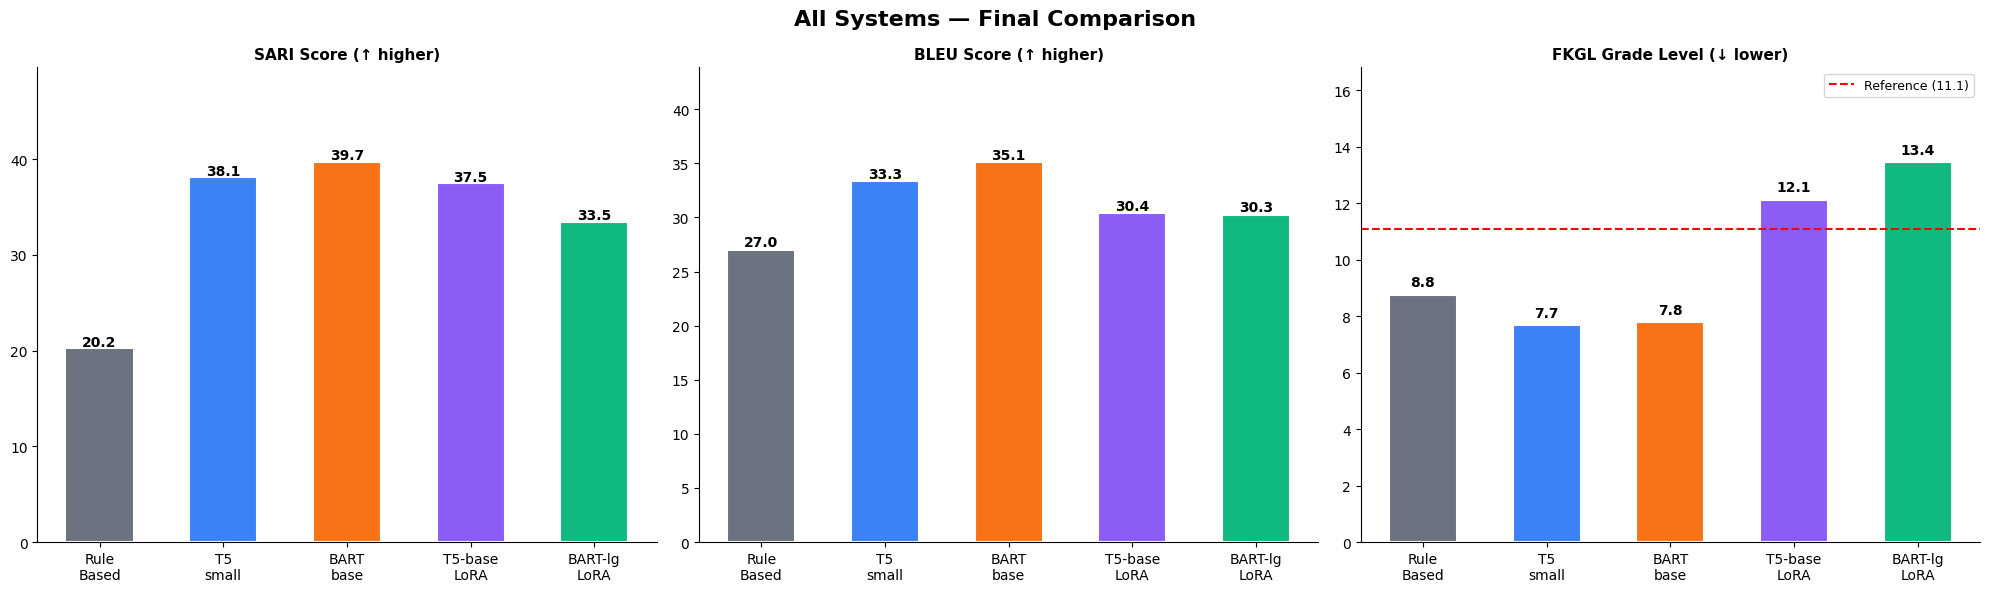

✅ Plot saved to Drive!

▶️  Now run Cell 14


In [ ]:
# ============================================================
# CELL 13 — Final comparison chart
# ============================================================
import matplotlib.pyplot as plt
import shutil

systems = ['Rule\nBased', 'T5\nsmall', 'BART\nbase', 'T5-base\nLoRA', 'BART-lg\nLoRA']
colors  = ['#6B7280', '#3B82F6', '#F97316', '#8B5CF6', '#10B981']

rb  = rb_scores
t5s = s2s_scores.get('t5_small',  {})
bbs = s2s_scores.get('bart_base', {})

sari_vals = [float(rb.get('sari',0)), float(t5s.get('sari',0)), float(bbs.get('sari',0)), t5b_sari, blg_sari]
bleu_vals = [float(rb.get('bleu',0)), float(t5s.get('bleu',0)), float(bbs.get('bleu',0)), t5b_bleu, blg_bleu]
fkgl_vals = [float(rb.get('fkgl_predicted',0)), float(t5s.get('fkgl_predicted',0)), float(bbs.get('fkgl_predicted',0)), t5b_fkgl, blg_fkgl]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('All Systems — Final Comparison', fontsize=16, fontweight='bold')

for ax, vals, title in zip(axes,
    [sari_vals, bleu_vals, fkgl_vals],
    ['SARI Score (↑ higher)', 'BLEU Score (↑ higher)', 'FKGL Grade Level (↓ lower)']):
    bars = ax.bar(systems, vals, color=colors, width=0.55, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)
    if 'FKGL' in title:
        ax.axhline(fkgl_ref, color='red', linestyle='--', linewidth=1.5,
                   label=f'Reference ({fkgl_ref:.1f})')
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Copy plot to Drive
try:
    shutil.copy('/content/full_comparison.png', f'{RESULTS_DIR}/full_comparison.png')
    print("✅ Plot saved to Drive!")
except:
    print("✅ Plot saved locally at /content/full_comparison.png")

print("\n▶️  Now run Cell 14")

---
## 🔍 CELL 14 — Qualitative Analysis (All 4 Systems)

In [ ]:
# ============================================================
# CELL 14 — Qualitative side-by-side for all systems
# ============================================================

# Load seq2seq predictions for side-by-side
s2s_pred_path = f'{RESULTS_DIR}/seq2seq/seq2seq_predictions.csv'
if os.path.exists(s2s_pred_path):
    s2s_df = pd.read_csv(s2s_pred_path)
    test_df['t5small_pred']  = s2s_df['t5_predicted'].values
    test_df['bartbase_pred'] = s2s_df['bart_predicted'].values
else:
    test_df['t5small_pred']  = 'N/A'
    test_df['bartbase_pred'] = 'N/A'

# Load rule-based predictions
rb_pred_path = f'{RESULTS_DIR}/rule_based/rule_based_predictions.csv'
if os.path.exists(rb_pred_path):
    rb_df = pd.read_csv(rb_pred_path)
    test_df['rb_pred'] = rb_df['predicted'].values
else:
    test_df['rb_pred'] = 'N/A'

print("="*75)
print("  QUALITATIVE COMPARISON — ALL 4 SYSTEMS")
print("="*75)

sample = test_df.sample(4, random_state=7)
for i, (_, row) in enumerate(sample.iterrows()):
    print(f"\n{'─'*75}")
    print(f"[Example {i+1}]")
    print(f"  COMPLEX        : {row['complex']}")
    print(f"  REFERENCE      : {row['simple']}")
    print(f"  Rule-Based     : {row.get('rb_pred', 'N/A')}")
    print(f"  T5-small       : {row.get('t5small_pred', 'N/A')}")
    print(f"  BART-base      : {row.get('bartbase_pred', 'N/A')}")
    print(f"  T5-base LoRA   : {row['t5base_predicted']}")
    print(f"  BART-lg LoRA   : {row['bartlarge_predicted']}")

  QUALITATIVE COMPARISON — ALL 4 SYSTEMS

───────────────────────────────────────────────────────────────────────────
[Example 1]
  COMPLEX        : officials thought that the log cabin was there at the time henson lived and worked on the grounds from when he was years old to when his owner sent him to kentucky.
  REFERENCE      : officials thought that the log cabin was there in henson s time.
  Rule-Based     : N/A
  T5-small       : officials thought that the log cabin was there at the time.
  BART-base      : officials thought that the log cabin was there at the time henson lived and worked on the property.
  T5-base LoRA   : officials thought that the log cabin was there at the time henson lived and worked on the grounds.
  BART-lg LoRA   : officials thought that the log cabin was there at the time henson lived and worked on the grounds from when he was years old to when his owner sent him to kentucky.

───────────────────────────────────────────────────────────────────────────
[E

---
## 💾 CELL 15 — Save Everything to Google Drive

In [ ]:
# ============================================================
# CELL 15 — Save all results to Drive
# ============================================================
import shutil, os

# ── Predictions CSV ────────────────────────────────────────
pred_csv = f'{LLM_OUT}/llm_predictions.csv'
test_df[['complex','simple','t5base_predicted','bartlarge_predicted']].to_csv(pred_csv, index=False)
print(f"✅ Predictions  → {pred_csv}")

# ── Scores JSON (already saved to LLM_OUT in Cell 11) ──────
scores_src = f'{LLM_OUT}/llm_scores.json'
if os.path.exists(scores_src):
    print(f"✅ Scores       → {scores_src}")
else:
    # Save again if missing
    with open(scores_src, 'w') as f:
        json.dump(llm_scores, f, indent=2)
    print(f"✅ Scores saved → {scores_src}")

# ── Plot ───────────────────────────────────────────────────
if os.path.exists('/content/full_comparison.png'):
    shutil.copy('/content/full_comparison.png', f'{LLM_OUT}/full_comparison.png')
    print(f"✅ Plot         → {LLM_OUT}/full_comparison.png")

# ── Plain text outputs ─────────────────────────────────────
with open(f'{LLM_OUT}/t5base_lora_output.txt', 'w') as f:
    f.write('\n'.join(t5b_preds))
with open(f'{LLM_OUT}/bartlarge_lora_output.txt', 'w') as f:
    f.write('\n'.join(blg_preds))
print(f"✅ Text outputs → {LLM_OUT}/")

# ── Master scores combining all systems ────────────────────
master = {
    'rule_based'      : rb_scores,
    't5_small'        : s2s_scores.get('t5_small',  {}),
    'bart_base'       : s2s_scores.get('bart_base', {}),
    't5_base_lora'    : llm_scores['t5_base_lora'],
    'bart_large_lora' : llm_scores['bart_large_lora'],
}
master_path = f'{LLM_OUT}/master_scores.json'
with open(master_path, 'w') as f:
    json.dump(master, f, indent=2)
print(f"✅ Master scores → {master_path}")

# ── Try copying LLM_OUT folder to Drive ───────────────────
try:
    drive_llm = f'{RESULTS_DIR}/llm_finetune'
    if os.path.exists(drive_llm):
        shutil.rmtree(drive_llm)
    shutil.copytree(LLM_OUT, drive_llm)
    print(f"✅ All copied to Drive → {drive_llm}")
except Exception as e:
    print(f"⚠️  Could not copy to Drive: {e}")
    print(f"   Files are safe locally at: {LLM_OUT}")

print(f"\n🎉 Stage 2 COMPLETE! Run Cell 16 for final summary.")

✅ Predictions  → /content/llm_finetune/llm_predictions.csv
✅ Scores       → /content/llm_finetune/llm_scores.json
✅ Plot         → /content/llm_finetune/full_comparison.png
✅ Text outputs → /content/llm_finetune/
✅ Master scores → /content/llm_finetune/master_scores.json
✅ All copied to Drive → /content/drive/MyDrive/NLP_Project/results/llm_finetune

🎉 Stage 2 COMPLETE! Run Cell 16 for final summary.


---
## 📋 CELL 16 — Final Summary

In [ ]:
# ============================================================
# CELL 16 — Final summary
# ============================================================
sep = "=" * 65
print(sep)
print("  STAGE 2 IMPLEMENTATION — COMPLETE!")
print(sep)
print()
print("  All 3 approaches implemented and evaluated:")
print()
print(f"  {'System':<22} {'SARI':>8} {'BLEU':>8} {'FKGL':>8} {'Coverage':>10}")
print(f"  {'-'*58}")

rows_data = [
    ('Rule-Based',       rb_scores.get('sari','-'),  rb_scores.get('bleu','-'),  rb_scores.get('fkgl_predicted','-'), '59.2%'),
    ('T5-small',         t5s.get('sari','-'),         t5s.get('bleu','-'),         t5s.get('fkgl_predicted','-'),        '100%'),
    ('BART-base',        bbs.get('sari','-'),         bbs.get('bleu','-'),         bbs.get('fkgl_predicted','-'),        '100%'),
    ('T5-base (LoRA)',   f'{t5b_sari:.2f}',           f'{t5b_bleu:.2f}',           f'{t5b_fkgl:.2f}',                    '100%'),
    ('BART-lg (LoRA)',   f'{blg_sari:.2f}',           f'{blg_bleu:.2f}',           f'{blg_fkgl:.2f}',                    '100%'),
]
for r in rows_data:
    print(f"  {r[0]:<22} {str(r[1]):>8} {str(r[2]):>8} {str(r[3]):>8} {r[4]:>10}")

print()
print(f"  FKGL source    : {fkgl_src:.2f}  (input complexity)")
print(f"  FKGL reference : {fkgl_ref:.2f}  (target simplicity)")
print()
print(f"  Saved to Drive:")
print(f"    results/rule_based/      ← Rule-based outputs")
print(f"    results/seq2seq/         ← T5-small & BART-base outputs")
print(f"    results/llm_finetune/    ← T5-base LoRA & BART-large LoRA")
print(f"    results/master_scores.json")
print(f"    models/t5_base_lora/")
print(f"    models/bart_large_lora/")
print(sep)
print("✅ Stage 2 (Implementation) COMPLETE!")
print("   Next → Stage 3: Analysis & Error Analysis")
print(sep)

  STAGE 2 IMPLEMENTATION — COMPLETE!

  All 3 approaches implemented and evaluated:

  System                     SARI     BLEU     FKGL   Coverage
  ----------------------------------------------------------
  Rule-Based                20.22    27.02     8.76      59.2%
  T5-small                  38.08    33.33     7.67       100%
  BART-base                 39.66     35.1     7.79       100%
  T5-base (LoRA)            37.45    30.43    12.11       100%
  BART-lg (LoRA)            33.47    30.27    13.44       100%

  FKGL source    : 16.53  (input complexity)
  FKGL reference : 11.07  (target simplicity)

  Saved to Drive:
    results/rule_based/      ← Rule-based outputs
    results/seq2seq/         ← T5-small & BART-base outputs
    results/llm_finetune/    ← T5-base LoRA & BART-large LoRA
    results/master_scores.json
    models/t5_base_lora/
    models/bart_large_lora/
✅ Stage 2 (Implementation) COMPLETE!
   Next → Stage 3: Analysis & Error Analysis
